In [10]:
pip install vaderSentiment

     -------------------------------------- 126.0/126.0 kB 2.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Import library yang dibutuhkan
import csv
import nltk
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [55]:
# Membaca dataset yang telah dilakukan proses preprocessing dan translate
df = pd.read_excel('data_clean_terjemah.xlsx')
df

,Data Clean
0,"Yes, that's how much he takes responsibility ..."
1,May God Almighty Allah bless the nation of th...
2,"Yes, I know you're sick, so it's a bit of a q..."
3,psi life
4,NaN
...,...
4994,viandi complains to his brother that it's del...
4995,aim for job opportunities so that people can ...
4996,buzzer comments
4997,"The comments are outraged, indeed the state ch..."


In [56]:
# Proses Cleaning Data dan Case Folding (Mengubah huruf menjadi kecil)
import re
import string
def filtering_text(text):
    # mengubah komentar menjadi huruf kecil
    text = text.lower()
    # menghilangkan url
    text = re.sub(r'https?:\/\/\S+','',text)
    # menghilangkan mention, link, hastag
    text = ' '.join(re.sub("([@#][A-Za-z0-9]+)|(\w+:\/\/\S+)"," ", text).split())
    #menghilangkan karakter byte (b')
    text = re.sub(r'(b\'{1,2})',"", text)
    # menghilangkan yang bukan huruf
    text = re.sub('[^a-zA-Z]', ' ', text)
    # menghilangkan digit angka
    text = re.sub(r'\d+', '', text)
    #menghilangkan tanda baca
    text = text.translate(str.maketrans("","",string.punctuation))
    # menghilangkan whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [57]:
# Mengganti nilai NaN dengan string kosong dan memastikan semua nilai adalah string
df['Data Clean'] = df['Data Clean'].fillna('').astype(str)

In [58]:
# Mencetak hasil dari cleaning dan case folding data
df['Data Clean'] = df['Data Clean'].apply(filtering_text)
df

,Data Clean
0,yes that s how much he takes responsibility fo...
1,may god almighty allah bless the nation of the...
2,yes i know you re sick so it s a bit of a ques...
3,psi life
4,
...,...
4994,viandi complains to his brother that it s deli...
4995,aim for job opportunities so that people can work
4996,buzzer comments
4997,the comments are outraged indeed the state cho...


In [59]:
# Import library Vader
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Fungsi yang berisi proses perhitungan dari labeling VADER
def calculate_sentiment_analyser(text):
    analyser = SentimentIntensityAnalyzer()
    sentiment_scores = analyser.polarity_scores(text)
    score = sentiment_scores['compound']
    
    if score >= 0.05:  # Menyesuaikan batas untuk positif
        sentiment_label = 'Positive'
    else:
        sentiment_label = 'Negative'
    
    return score, sentiment_label

In [60]:
# Melakukan labeling menggunakan vader
df[['sentiment_analyser_score', 'sentiment_analyser_label']] = df['Data Clean'].apply(calculate_sentiment_analyser).apply(pd.Series)
df

,Data Clean,sentiment_analyser_score,sentiment_analyser_label
0,yes that s how much he takes responsibility fo...,0.4019,Positive
1,may god almighty allah bless the nation of the...,0.8225,Positive
2,yes i know you re sick so it s a bit of a ques...,-0.1531,Negative
3,psi life,0.0000,Negative
4,,0.0000,Negative
...,...,...,...
4994,viandi complains to his brother that it s deli...,0.6369,Positive
4995,aim for job opportunities so that people can work,0.3818,Positive
4996,buzzer comments,0.0000,Negative
4997,the comments are outraged indeed the state cho...,-0.5423,Negative


In [25]:
# Menyimpan Hasil Labeling kedalam Excel
df.to_excel('LabelingFixSekali.xlsx', index=False)
print('Data Tersimpan')

Data Tersimpan


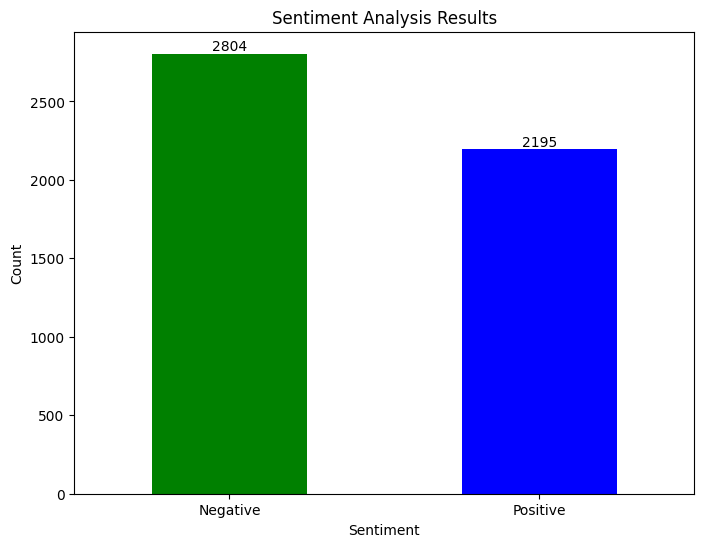

In [61]:
import matplotlib.pyplot as plt

# Count the number of each sentiment label
sentiment_counts = df['sentiment_analyser_label'].value_counts()

# Plotting the bar plot
plt.figure(figsize=(8, 6))
bars = sentiment_counts.plot(kind='bar', color=['green', 'blue'])
plt.title('Sentiment Analysis Results')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Annotate each bar with its count
for i, count in enumerate(sentiment_counts):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.show()

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Membuat objek TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Melakukan pembobotan TF-IDF pada data clean
X_tfidf = vectorizer.fit_transform(df['Data Clean'])

# Cetak hasil TF-IDF
print("Hasil TF-IDF:")
print(X_tfidf)

Hasil TF-IDF:
  (0, 2635)	0.18310679897050047
  (0, 3626)	0.46647262013420254
  (0, 1929)	0.1898278085157452
  (0, 4417)	0.3737177743909985
  (0, 5213)	0.37729384658207316
  (0, 2276)	0.2859418577292307
  (0, 3408)	0.39447949624497525
  (0, 2407)	0.28811507302994377
  (0, 5301)	0.22052353498465013
  (0, 5838)	0.24861060443402405
  (1, 1659)	0.17401157716692242
  (1, 2748)	0.16203508749479553
  (1, 5757)	0.10158132071374877
  (1, 1125)	0.09302510565368197
  (1, 4134)	0.13018834573035307
  (1, 490)	0.16203508749479553
  (1, 4910)	0.09984042056082951
  (1, 700)	0.10491059048862568
  (1, 5375)	0.059910474540051835
  (1, 3387)	0.18884580848814103
  (1, 4950)	0.16533410811698632
  (1, 489)	0.27913511739225383
  (1, 5740)	0.185088315907635
  (1, 3623)	0.3384720426771282
  (1, 3171)	0.14066530043916858
  :	:
  (4995, 5782)	0.26494631246820666
  (4995, 3862)	0.2102582208133515
  (4995, 4910)	0.29808302700194755
  (4995, 1929)	0.21889860715991494
  (4995, 5301)	0.2542951690353458
  (4996, 738)	0

In [81]:
# Simpan hasil TF-IDF ke dalam file CSV
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.to_csv('hasil_tfidf.csv', index=False)

In [82]:
# Melakukan Imbalance Dataset menggunakan SMOTE
# Proses SMOTE untuk data balancing
from imblearn.over_sampling import SMOTE

# Jumlah data sebelum SMOTE
print("Jumlah data sebelum SMOTE:", X_tfidf.shape[0])

# Melakukan SMOTE untuk balancing data
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_tfidf, df['sentiment_analyser_label'])

# Jumlah data setelah SMOTE
print("Jumlah data setelah SMOTE:", X_balanced.shape[0])

Jumlah data sebelum SMOTE: 4999
Jumlah data setelah SMOTE: 5608


C:\Users\abimn\AppData\Local\Temp\ipykernel_17468\2930375584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_balanced, x='sentiment', palette={'Positive': 'blue', 'Negative': 'red'})


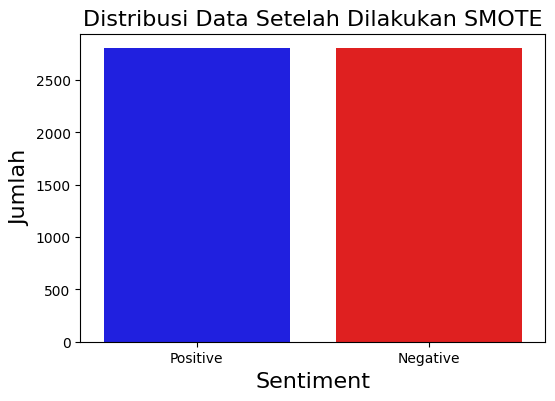

Jumlah data bersentimen positif setelah SMOTE: 2804
Jumlah data bersentimen negatif setelah SMOTE: 2804
Jumlah data setelah dilakukan SMOTE :  5608


In [85]:
# Import library seaborn untuk visualisasi
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat DataFrame baru dari data yang telah di-balancing
df_balanced = pd.DataFrame(X_balanced.toarray(), columns=vectorizer.get_feature_names_out())
df_balanced['sentiment'] = y_balanced

# Membuat visualisasi bar plot untuk menampilkan distribusi kelas 'Positive' dan 
plt.figure(figsize=(6, 4))
sns.countplot(data=df_balanced, x='sentiment', palette={'Positive': 'blue', 'Negative': 'red'})
plt.title('Distribusi Data Setelah Dilakukan SMOTE', fontsize=16)
plt.xlabel('Sentiment', fontsize=16)
plt.ylabel('Jumlah', fontsize=16)
plt.show()

# Menghitung jumlah data dengan sentimen positif dan negatif setelah SMOTE
positive_count_smote = (df_balanced['sentiment'] == 'Positive').sum()
negative_count_smote = (df_balanced['sentiment'] == 'Negative').sum()
total_smote = len(df_balanced)

# Menampilkan jumlah data dengan sentimen positif dan negatif setelah SMOTE
print("Jumlah data bersentimen positif setelah SMOTE:", positive_count_smote)
print("Jumlah data bersentimen negatif setelah SMOTE:", negative_count_smote)
print("Jumlah data setelah dilakukan SMOTE : ", total_smote)

In [12]:
#pip install imbalanced-learn

In [93]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import time
import pandas as pd

def naive_bayes_model(X, y, k_fold_list):
    nbhasil = []
    
    for alpha in alpha_list:
        for k_fold in k_fold_list:
            kfold = KFold(n_splits=k_fold, shuffle=True, random_state=42)
            nb_results = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'time': [], 'conf_matrix': []}
            for train_index, test_index in kfold.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                nb_classifier = MultinomialNB()

                start_time = time.time()  # Waktu mulai

                nb_classifier.fit(X_train, y_train)

                end_time = time.time()  # Waktu selesai

                prediksi = nb_classifier.predict(X_test)

                accuracy  = accuracy_score(y_test, prediksi) * 100
                precision = precision_score(y_test, prediksi, average='weighted') * 100
                recall    = recall_score(y_test, prediksi, average='weighted') * 100
                f1        = f1_score(y_test, prediksi, average='weighted') * 100
                conf_matrix = confusion_matrix(y_test, prediksi)

                nb_results['accuracy'].append(accuracy)
                nb_results['precision'].append(precision)
                nb_results['recall'].append(recall)
                nb_results['f1'].append(f1)
                nb_results['time'].append(end_time - start_time)  # Waktu yang dibutuhkan untuk pelatihan dan pengujian
                nb_results['conf_matrix'].append(conf_matrix)

            # Menghitung rata-rata hasil dari k-Fold Cross-Validation
            NBaccuracy  = round(np.mean(nb_results['accuracy']), 2)
            NBprecision = round(np.mean(nb_results['precision']), 2)
            NBrecall    = round(np.mean(nb_results['recall']), 2)
            NBf1score   = round(np.mean(nb_results['f1']), 2)
            NBtime      = round(np.mean(nb_results['time']), 2)  # Waktu rata-rata dari seluruh lipatan
            
            # Confusion Matrix (average)
            avg_conf_matrix = np.mean(nb_results['conf_matrix'], axis=0).astype(int)

            # Cross-validation
            cv_scores = cross_val_score(MultinomialNB(alpha=alpha), X, y, cv=k_fold)
            cv_accuracy = np.mean(cv_scores) * 100
            cv_std_dev = np.std(cv_scores) * 100

            print(f"Naive Bayes k-fold={k_fold}")
            print("Accuracy      : %.2f%%" % NBaccuracy)
            print("Precision     : %.2f%%" % NBprecision)
            print("Recall        : %.2f%%" % NBrecall)
            print("F1-score      : %.2f%%" % NBf1score)
            print("Average Time  : %.2f second" % NBtime)
            print("Confusion Matrix:\n", avg_conf_matrix)
            print("Cross-Val Accuracy: %.2f%% (+/- %.2f%%)" % (cv_accuracy, cv_std_dev))
            print()

            # Simpan hasil ke dalam list
            nbhasil.append({
                "k_fold"      : k_fold,
                "Accuracy"    : NBaccuracy,
                "Precision"   : NBprecision,
                "Recall"      : NBrecall,
                "F1-Score"    : NBf1score,
                "Average Time": NBtime,
                "Confusion Matrix": avg_conf_matrix,
                "Cross-Val Accuracy": cv_accuracy,
                "Cross-Val Std Dev": cv_std_dev
            })

    return nbhasil

# Daftar k-fold yang ingin diuji
k_fold_list = [3, 5, 7, 9, 10]

# Contoh data, harus disesuaikan dengan dataset sebenarnya
# Misalnya dataset iris yang sudah dalam bentuk dataframe
from sklearn.datasets import load_iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Memanggil fungsi
model_nb = naive_bayes_model(X, y, k_fold_list)

# Tampilkan hasil dalam bentuk DataFrame
results_df_nb = pd.DataFrame(model_nb)

print("Hasil Uji Model Naive Bayes:")
print(results_df_nb)


Naive Bayes k-fold=3
Accuracy      : 93.33%
Precision     : 95.01%
Recall        : 93.33%
F1-score      : 93.17%
Average Time  : 0.00 second
Confusion Matrix:
 [[16  0  0]
 [ 0 14  2]
 [ 0  1 15]]
Cross-Val Accuracy: 95.33% (+/- 0.94%)

Naive Bayes k-fold=5
Accuracy      : 92.00%
Precision     : 93.99%
Recall        : 92.00%
F1-score      : 91.91%
Average Time  : 0.00 second
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  8]]
Cross-Val Accuracy: 95.33% (+/- 4.52%)

Naive Bayes k-fold=7
Accuracy      : 89.24%
Precision     : 93.15%
Recall        : 89.24%
F1-score      : 89.07%
Average Time  : 0.00 second
Confusion Matrix:
 [[7 0 0]
 [0 5 1]
 [0 0 6]]
Cross-Val Accuracy: 95.95% (+/- 6.45%)

Naive Bayes k-fold=9
Accuracy      : 92.08%
Precision     : 94.13%
Recall        : 92.08%
F1-score      : 92.14%
Average Time  : 0.00 second
Confusion Matrix:
 [[5 0 0]
 [0 4 0]
 [0 0 5]]
Cross-Val Accuracy: 95.34% (+/- 6.16%)

Naive Bayes k-fold=10
Accuracy      : 92.00%
Precision     : 94.83%
Re

In [95]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

def random_forest_model(X, y, k_fold_list, n_estimators_list):
    rfhasil = []
    
    for k_fold in k_fold_list:
        for n_estimators in n_estimators_list:
            kfold = KFold(n_splits=k_fold, shuffle=True, random_state=42)
            rf_results = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'time': [], 'conf_matrix': []}
            for train_index, test_index in kfold.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                rf_classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=42, criterion='entropy')

                start_time = time.time()  # Waktu mulai
                rf_classifier.fit(X_train, y_train)
                end_time = time.time()  # Waktu selesai

                prediksi = rf_classifier.predict(X_test)
                
                time_rf = end_time - start_time
                accuracy = accuracy_score(y_test, prediksi) * 100
                precision = precision_score(y_test, prediksi, average='weighted') * 100
                recall = recall_score(y_test, prediksi, average='weighted') * 100
                f1 = f1_score(y_test, prediksi, average='weighted') * 100
                conf_matrix = confusion_matrix(y_test, prediksi)

                rf_results['accuracy'].append(accuracy)
                rf_results['precision'].append(precision)
                rf_results['recall'].append(recall)
                rf_results['f1'].append(f1)
                rf_results['time'].append(time_rf)  # Waktu yang dibutuhkan untuk pelatihan dan pengujian
                rf_results['conf_matrix'].append(conf_matrix)
                
            # Menghitung rata-rata hasil dari k-Fold Cross-Validation
            RFaccuracy = round(np.mean(rf_results['accuracy']), 2)
            RFprecision = round(np.mean(rf_results['precision']), 2)
            RFrecall = round(np.mean(rf_results['recall']), 2)
            RFf1score = round(np.mean(rf_results['f1']), 2)
            RFtime = round(np.mean(rf_results['time']), 2)  # Waktu rata-rata dari seluruh lipatan
            
            # Confusion Matrix (average)
            avg_conf_matrix = np.mean(rf_results['conf_matrix'], axis=0).astype(int)
            
            # Cross-validation
            cv_scores = cross_val_score(rf_classifier, X, y, cv=k_fold)
            cv_accuracy = np.mean(cv_scores) * 100
            cv_std_dev = np.std(cv_scores) * 100
            
            print(f"Random Forest dengan k-fold={k_fold} dan n_estimators={n_estimators}")
            print("Accuracy      : %.2f%%" % RFaccuracy)
            print("Precision     : %.2f%%" % RFprecision)
            print("Recall        : %.2f%%" % RFrecall)
            print("F1-score      : %.2f%%" % RFf1score)
            print("Running Time  : %.2f second" % RFtime)
            print("Confusion Matrix:\n", avg_conf_matrix)
            print("Cross-Val Accuracy: %.2f%% (+/- %.2f%%)" % (cv_accuracy, cv_std_dev))
            print()
           
            # Simpan hasil ke dalam list 
            rfhasil.append({
                "k_fold": k_fold,
                "n_estimators": n_estimators,
                "Accuracy": RFaccuracy,
                "Precision": RFprecision,
                "Recall": RFrecall,
                "F1-Score": RFf1score,
                "Run Time": RFtime,
                "Confusion Matrix": avg_conf_matrix,
                "Cross-Val Accuracy": cv_accuracy,
                "Cross-Val Std Dev": cv_std_dev
            })

    return rfhasil

# Daftar k-fold dan n_estimators yang ingin diuji
k_fold_list = [3, 5, 7, 9, 10]
n_estimators_list = [10, 30, 50, 70, 90, 100]

# Contoh data, harus disesuaikan dengan dataset sebenarnya
# Misalnya dataset iris yang sudah dalam bentuk dataframe
from sklearn.datasets import load_iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Memanggil fungsi
model = random_forest_model(X, y, k_fold_list, n_estimators_list)

# Tampilkan hasil dalam bentuk DataFrame
results_df = pd.DataFrame(model)

print("Hasil Uji Model Random Forest:")
print(results_df)


Random Forest dengan k-fold=3 dan n_estimators=10
Accuracy      : 94.67%
Precision     : 94.88%
Recall        : 94.67%
F1-score      : 94.67%
Running Time  : 0.01 second
Confusion Matrix:
 [[16  0  0]
 [ 0 15  1]
 [ 0  1 15]]
Cross-Val Accuracy: 95.33% (+/- 1.89%)

Random Forest dengan k-fold=3 dan n_estimators=30
Accuracy      : 95.33%
Precision     : 95.52%
Recall        : 95.33%
F1-score      : 95.33%
Running Time  : 0.02 second
Confusion Matrix:
 [[16  0  0]
 [ 0 15  1]
 [ 0  1 15]]
Cross-Val Accuracy: 96.67% (+/- 1.89%)

Random Forest dengan k-fold=3 dan n_estimators=50
Accuracy      : 95.33%
Precision     : 95.52%
Recall        : 95.33%
F1-score      : 95.33%
Running Time  : 0.05 second
Confusion Matrix:
 [[16  0  0]
 [ 0 15  1]
 [ 0  1 15]]
Cross-Val Accuracy: 96.67% (+/- 1.89%)

Random Forest dengan k-fold=3 dan n_estimators=70
Accuracy      : 95.33%
Precision     : 95.52%
Recall        : 95.33%
F1-score      : 95.33%
Running Time  : 0.07 second
Confusion Matrix:
 [[16  0  0]
 